In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pyro
from pyro.infer.autoguide import AutoLowRankMultivariateNormal
from pyro.infer import Predictive
import pyro.distributions as dist
from pyro.optim import Adam
import random
import pandas as pd
import scipy.io as sio
from sklearn.preprocessing import StandardScaler

# import user-defined files
from utils.Reservoir import Reservoir
from utils.ESNVariational import ESNVariational
from utils.ESNDataset import ESNDataset
from utils.prediction_curve import prediction_curve
from utils.construct_dataset import construct_dataset
from methods_2 import evaluate_metrics


In [2]:
# Load the MAT file
mat_file = sio.loadmat('100307.REST1.LR.SchaeferS.ptseries.mat')
 
print(mat_file.keys())

dict_keys(['__header__', '__version__', '__globals__', 'tseries'])


In [3]:
data = torch.from_numpy(mat_file['tseries']).float()

In [4]:
## PYRO MODEL
# states is a batch of states of size (batch dimension, neurons per state)
def model_fn(states, scale = 0.1, targets=None):
    N_neurons = states.shape[1]
    # We sample the Readout Weights R
    # .to_event(2) ensures Pyro treats this as a matrix, not independent scalars
    R = pyro.sample("R", dist.Normal(torch.zeros(N_neurons, 119), 1.0).to_event(2))
    
    # Linear projection to find the mean load
    mu = (states @ R)
    
    # Observation noise (how much we expect the real data to fluctuate around mu)
    sigma = pyro.sample("sigma", dist.HalfNormal(scale))
    
    with pyro.plate("data", states.shape[0]):
        return pyro.sample("obs", dist.Normal(mu, sigma).to_event(1), obs=targets)

In [5]:
# PARAMETERS

N_NEURONS = 200
INPUT_DIM = data.shape[0] # equals to output dim

LR = 0.01
EPOCHS = 100

# Setup Optimizer
optimizer = pyro.optim.Adam({"lr": LR})

In [6]:
# PYRO GUIDE

RANK = int(np.sqrt(N_NEURONS))  # Rank for the Multivariate Normal
guide = AutoLowRankMultivariateNormal(model_fn, rank=RANK)

In [7]:
# Initialize the ESNVariational
esn_var = ESNVariational(
    N_NEURONS, 
    INPUT_DIM, 
    model_fn, 
    guide, 
    optimizer, 
    spectral_radius=0.9,
    scale = 0.1
)


In [8]:
# Generate Torch datasets
train_ds, valid_ds = construct_dataset(esn_var.reservoir, data.T, train_split=0.7, burnin=100)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

In [9]:
# TRAIN
history = esn_var.train(train_loader, epochs=EPOCHS)

Training Pyro ESN:   1%|          | 1/100 [00:06<10:33,  6.40s/it, Loss=422235.7261]

Epoch 0 | Total ELBO Loss: 422235.7261


Training Pyro ESN: 100%|██████████| 100/100 [00:26<00:00,  3.73it/s, Loss=2634.2633]


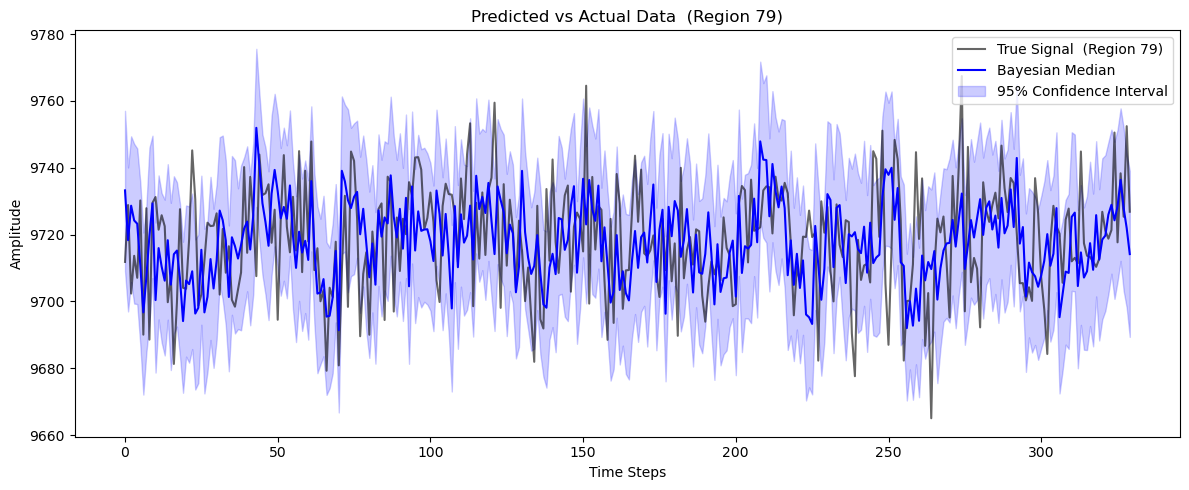

In [10]:
# PREDICT & PLOT
scaler = {'mean': train_ds.mean, 'std': train_ds.std}
y_true, y_samples, y_mean, upper, lower = prediction_curve(esn_var, valid_ds, scaler, region_idx = 79)

In [11]:
ecov, cal, mcrps = evaluate_metrics(y_pred_samples=y_samples, y_true = y_true)

In [12]:
ranges = y_true.max(dim=0).values - y_true.min(dim=0).values
n_mcrps_per_region = mcrps / ranges

In [13]:
n_mcrps_per_region.mean().item() * 100

9.295248985290527

## Random search

In [14]:
# parameters space
spectral_radius_list = [0.1,0.3,0.5,0.7,0.9,1.1]
neurons_list = [16, 32, 64, 128, 256, 512]
activations_list = [nn.ReLU(), nn.Tanh()] 
learning_rates = [0.0001, 0.001, 0.01]
scales = [0.01, 0.1, 1.0]

# ranges for each region (used to normalize the mcrps)
ranges = y_true.max(dim=0).values - y_true.min(dim=0).values
      

In [15]:
num_iterations = 2
results = []

for i in range(num_iterations):
    # Reset pyro paramteres between trials
    pyro.clear_param_store()
    
    # Sample parameters 
    n = random.choice(neurons_list)
    act_name = random.choice(activations_list)
    lr = random.choice(learning_rates)
    s = random.choice(scales)
    spectral_radius = random.choice(spectral_radius_list)
    
    print(f"\n--- Trial {i+1}/{num_iterations} ---")
    print(f"Parameters: Neurons={n}, Activation={act_name}, LR={lr}, Scale={s}, Spectral radius={spectral_radius}")

    try:
        optimizer = pyro.optim.Adam({"lr": lr})

        # PYRO GUIDE

        RANK = int(np.sqrt(n))  # Rank for the Multivariate Normal
        guide = AutoLowRankMultivariateNormal(model_fn, rank=RANK)

        # istantiate the model
        esn_var = ESNVariational(
            N=n, 
            K=INPUT_DIM, 
            pyro_model=model_fn, 
            pyro_guide=guide, 
            optimizer=optimizer,
            spectral_radius=spectral_radius,
            scale=s
        )
        
        esn_var.reservoir.activation = act_name 

        # train
        esn_var.train(train_loader, epochs=100)

        # evaluate
        y_true_eval, y_samples_eval, *_ = prediction_curve(esn_var, valid_ds, scaler, plot = False)
        
        # metrics
        ecov, cal, mcrps = evaluate_metrics(y_samples_eval, y_true_eval)

        # convert the vector of mrcps in a normalized avergae
        n_mcrps = mcrps / ranges

        avg_mcrps = n_mcrps.mean().item()

        results.append({
            'neurons': n,
            'activation': act_name,
            'lr': lr,
            'scale': s,
            'ecov': ecov,
            'cal': cal,
            'mcrps': avg_mcrps
        })

    except Exception as e:
        print(f"Error at iteration: {e}")
        


--- Trial 1/2 ---
Parameters: Neurons=256, Activation=ReLU(), LR=0.001, Scale=0.01, Spectral radius=0.7


Training Pyro ESN:   0%|          | 0/100 [00:00<?, ?it/s]

Training Pyro ESN:   1%|          | 1/100 [00:00<00:23,  4.19it/s, Loss=35999062.8181]

Epoch 0 | Total ELBO Loss: 47382838.2478


Training Pyro ESN: 100%|██████████| 100/100 [00:22<00:00,  4.54it/s, Loss=2411463.0057]



--- Trial 2/2 ---
Parameters: Neurons=128, Activation=Tanh(), LR=0.001, Scale=1.0, Spectral radius=1.1


Training Pyro ESN:   1%|          | 1/100 [00:00<00:22,  4.49it/s, Loss=3974.6946]

Epoch 0 | Total ELBO Loss: 4577.8702


Training Pyro ESN: 100%|██████████| 100/100 [00:19<00:00,  5.10it/s, Loss=1190.2148]


In [16]:
df_results = pd.DataFrame(results)
df_results['ecov_dist'] = (df_results['ecov'] - 0.95).abs()

# Order the results
best_models = df_results.sort_values(by=['cal', 'ecov_dist', 'mcrps'])

print(best_models.head(5))


   neurons activation     lr  scale      ecov       cal     mcrps  ecov_dist
1      128     Tanh()  0.001   1.00  0.943494  0.000026  0.152971   0.006506
0      256     ReLU()  0.001   0.01  0.784619  0.013675  0.160836   0.165381


## test dataset

In [17]:
data_test = torch.from_numpy(sio.loadmat('100307.REST2.LR.SchaeferS.ptseries.mat')['tseries']).float()

## Trial for visualization

In [18]:
num_samples = y_samples.shape[0]
    
# quantiles grid
tau_grid = torch.linspace(0.0, 1.0, 101)


# shape: [101, Time, Regions]
q = torch.quantile(y_samples, tau_grid, dim=0)


# y_true_extended has shape [1, Time, Regions] for broadcasting
y_true_extended = y_true.unsqueeze(0)
errors = y_true_extended - q  # [101, Time, Regions]

# Pinball Loss
# tau_grid_extended has shape [101, 1, 1] --> done for broadcasting
tau_grid_extended = tau_grid.view(-1, 1, 1)
loss = torch.max(tau_grid_extended * errors, (tau_grid_extended - 1) * errors)

In [19]:
data_heatmap = loss.mean(dim=0).T

In [20]:
ranges_extended = ranges.repeat(data_heatmap.shape[1],1).T

In [21]:
ranges_extended

tensor([[259.6738, 259.6738, 259.6738,  ..., 259.6738, 259.6738, 259.6738],
        [174.9541, 174.9541, 174.9541,  ..., 174.9541, 174.9541, 174.9541],
        [224.0137, 224.0137, 224.0137,  ..., 224.0137, 224.0137, 224.0137],
        ...,
        [248.6143, 248.6143, 248.6143,  ..., 248.6143, 248.6143, 248.6143],
        [211.9736, 211.9736, 211.9736,  ..., 211.9736, 211.9736, 211.9736],
        [221.4307, 221.4307, 221.4307,  ..., 221.4307, 221.4307, 221.4307]])

In [22]:
data_heatmap = (data_heatmap/ranges_extended) * 100

In [23]:
data_heatmap

tensor([[ 2.4311,  2.7810,  3.9083,  ..., 11.9410,  9.0092,  5.0232],
        [ 9.5805,  2.1566,  3.2092,  ..., 11.7972,  3.7166,  2.6264],
        [ 1.9162,  1.4927,  1.6335,  ...,  2.8864,  5.0807,  4.4612],
        ...,
        [ 4.1523,  4.1273,  2.3499,  ...,  1.7670,  1.6133,  6.3816],
        [ 2.3455,  5.4928, 16.2209,  ...,  1.8701,  1.3934,  8.5874],
        [ 3.7589,  4.8767, 11.3836,  ...,  5.1063,  2.1438,  7.6852]])

Text(170.72222222222223, 0.5, 'Regions')

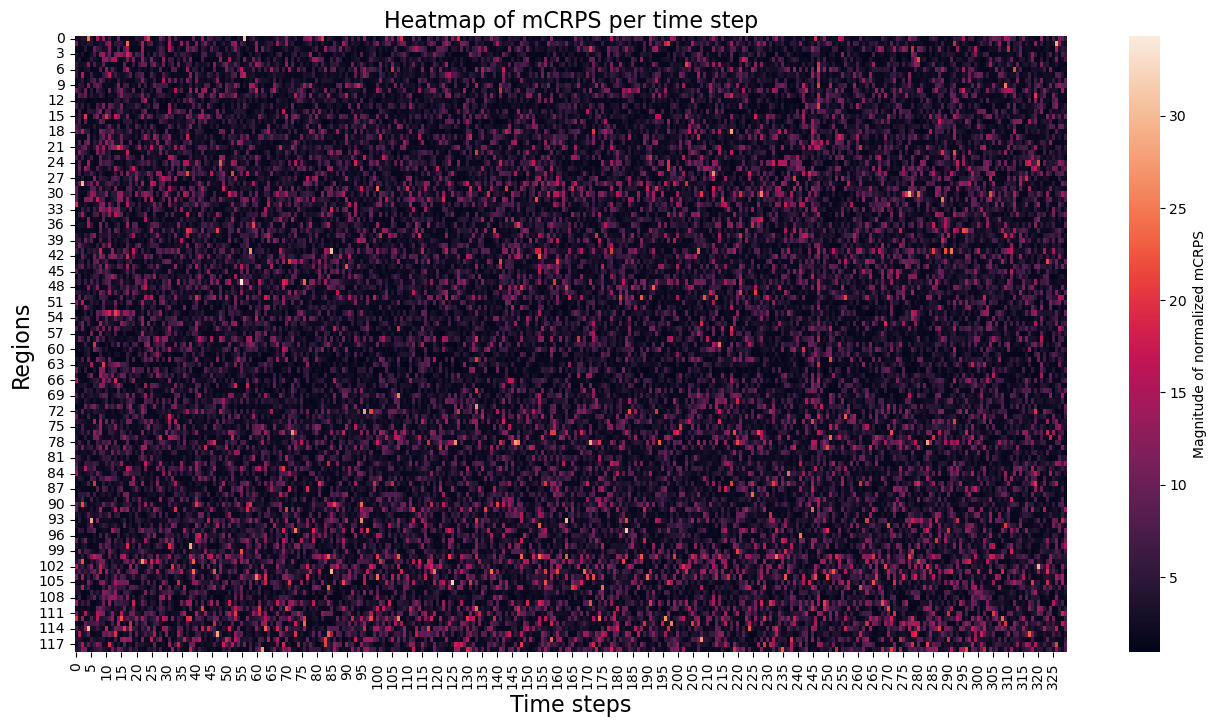

In [36]:
import seaborn as sns

plt.figure(figsize=(16,8))
plt.title('Heatmap of mCRPS per time step', fontsize = 16)

ax = sns.heatmap(data_heatmap, cbar_kws={'label': 'Magnitude of normalized mCRPS'})

# Set the labels

ax.set_xlabel("Time steps", fontsize=16)
ax.set_ylabel("Regions", fontsize=16)